# Brisk-Light Black Hole Imaging from GRMHD Simulations

Generates a movie using the brisk-light prescription (p = 0): one representative
GRMHD snapshot per lensing band, selected at the modal emission time t̄_n of
that band. Geodesics are computed once and reused for every frame.

In [1]:
const MODEL      = "iharm"
const MBH        = 6.2e9
const BRISK_LIGHT = true   

include("../src/main.jl")

Using model: iharm, change src/set_globals.jl to modify.


find_dump_path_for_time (generic function with 1 method)

In [2]:
#const all_dumps_path = "../../data/kharma_dumps/tmp.%05d.h5"
const all_dumps_path = "/home/pedro/kharma_dumps/tmp.%05d.h5"

"/home/pedro/kharma_dumps/tmp.%05d.h5"

In [3]:
const dump_first = 0
const dump_last  = 10
const ImageCadence = 10

dump_list  = [Printf.format(Printf.Format(all_dumps_path), i) 
              for i in dump_first:dump_last]
dump_times = [get_dump_time(i) for i in dump_first:dump_last]

params_brisklight = OfBriskLight(NBAND, zeros(Float64, NBAND +1), ImageCadence, 0.0)

println("Total dumps available: ", length(dump_list))
println("Time range: $(dump_times[1]) M  →  $(dump_times[end]) M")

Total dumps available: 11
Time range: 1100.0026804973966 M  →  2100.0055612048927 M


In [4]:
trat_large       = 20.
const trat_small     = 1.
const beta_crit      = 1.0
const th_beg         = 1.74e-2
const sigma_cut      = 1.0
const sigma_cut_high = -1.0

-1.0

In [5]:
const params = read_header(dump_list[1])

Initializing grid from: /home/pedro/kharma_dumps/tmp.00000.h5


custom electron model loaded from dump file...
Using mixed tp_over_te with trat_small = 1, trat_large = 20, and beta_crit = 1
Using Funky Modified Kerr-Schild coordinates FMKS
MKS parameters a: 0.937500 hslope: 0.300000 Rin: 1.001876 Rout: 1000.000000
FMKS parameters poly_xt: 0.820000 poly_alpha: 14.000000 mks_smooth: 0.500000 poly_norm: 0.757817
Grid start (startx): 1.874000951149755e-03, 0.000000000000000e+00, 0.000000000000000e+00 stop (stopx): 6.907755278982137e+00, 1.000000000000000e+00, 6.283185307179586e+00
grid dx: 5.395219748461709e-02, 7.812500000000000e-03, 6.283185307179586e+00


GlobalParams(2, 2, 0, 1.666667, 1.3333333333333333, 1.6666666666666667, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 0.9375, 0.3, 1.001875757988324, 1000.0, 0.82, 14.0, 0.5, 0.7578173169894967, 0.0, 0.0, 0.0, 0.0, 0.0, 128, 128, 1, [0.0, 0.05395219748461709, 0.0078125, 6.283185307179586], [0.0, 0.001874000951149755, 0.0, 0.0], [1.0, 6.907755278982137, 1.0, 6.283185307179586], [0.0, 0.0, 0.0, 0.0], [0.0, 6.907755278982137, 1.0, 6.283185307179586], 1.001875757988324, 100.0)

In [6]:
const ro      = 1000.0
const th      = 163.0
const phi     = 0.0

const res     = 128
const pixels_x = 128
const pixels_y = 128

const SourceD = 16.9e6 * PC
const Rh      = 1 + sqrt(1. - params.a * params.a)
const freq    = 230e9

const DXsize  = SourceD / L_unit / MUAS_PER_RAD * 160
const DYsize  = SourceD / L_unit / MUAS_PER_RAD * 160
const fovx    = DXsize / ro
const fovy    = DYsize / ro
const xoff    = 0.0
const yoff    = 0.0

println("Resolution:        $(pixels_x) × $(pixels_y) pixels")
println("Inclination:       th = $(th)° (equivalent to $(180 - th)° from jet axis)")
println("Spin:              a = $(params.a)")
println("Frequency:         $(freq/1e9) GHz")
println("Field of view:     $(DXsize * L_unit / SourceD * MUAS_PER_RAD) μas")

Resolution:        128 × 128 pixels
Inclination:       th = 163.0° (equivalent to 17.0° from jet axis)
Spin:              a = 0.9375
Frequency:         230.0 GHz
Field of view:     159.99999999999997 μas


In [7]:
# Ray tracing — geodesics are geometry only and reused for every frame.
Xcamera = MVec4(camera_position(ro, th, phi, params.a, params.Rout))

const freq_unitless = freq * HPL / (ME * CL * CL)

midplane_crossings = zeros(Int, pixels_x, pixels_y)
nsteps             = zeros(Int, pixels_x, pixels_y)

const nthreads = Threads.nthreads() + 1
const maxnstep = 15000

dummy_svec = @SVector zeros(4)
dummy_traj = OfTrajS(0.0, dummy_svec, dummy_svec, dummy_svec, dummy_svec)

thread_trajs = [Vector{OfTrajS}(undef, maxnstep) for _ in 1:nthreads]
for t in 1:nthreads
    for k in 1:maxnstep
        thread_trajs[t][k] = dummy_traj
    end
end

const all_geodesics = Matrix{Vector{OfTrajS}}(undef, pixels_x, pixels_y)

p = Progress(pixels_x * pixels_y; desc="Raytracing...", showspeed=true, barlen=30)
ProgressMeter.ijulia_behavior(:clear)

Threads.@threads for i in 0:(pixels_x - 1)
    tid = Threads.threadid()
    for j in 0:(pixels_y - 1)
        nstep, midplane_crossings[i+1, j+1] = get_pixel(
            thread_trajs[tid], i, j, Xcamera,
            fovx, fovy, freq_unitless,
            pixels_x, pixels_y, params.a,
            Rh, params.Rout, params.rmax_geo, xoff, yoff
        )
        nsteps[i+1, j+1]          = nstep
        all_geodesics[i+1, j+1]   = thread_trajs[tid][1:nstep]
        ProgressMeter.next!(p)
    end
end
finish!(p)

thread_trajs = nothing
GC.gc()
println("Ray tracing complete.")

Raytracing... 100%|██████████████████████████████| Time: 0:00:08 ( 0.52 ms/it)m


Ray tracing complete.


In [10]:
# Brisk-light parameters.
# image_cadence: time between output frames in units of M.
# t_obs_start / t_obs_end: observer-time range for the movie.
# These mirror the role of ImageCadence and the dump time window in slow-light.
const image_cadence = 10.0
const t_obs_start   = dump_times[1]
const t_obs_end     = dump_times[end]

params_brisklight = OfBriskLight(
    NBAND,                       # n_bands
    zeros(Float64, NBAND + 1),       # modal_times (filled per frame)
    image_cadence,
    t_obs_start                  # t_obs (updated per frame)
)

# One IharmData slot per lensing band (one snapshot loaded per band per frame).
simulation_data = Vector{IharmData}(undef, NBAND + 1)

println("Brisk-light configured:")
println("  Bands retained : $NBAND")
println("  Image cadence  : $image_cadence M")
println("  t_obs range    : $t_obs_start → $t_obs_end M")

Brisk-light configured:
  Bands retained : 3
  Image cadence  : 10.0 M
  t_obs range    : 1100.0026804973966 → 2100.0055612048927 M


In [ ]:
process_brisklight_images!(
    params_brisklight,
    simulation_data,
    all_geodesics,
    nsteps,
    midplane_crossings,
    params,
    pixels_x,
    pixels_y,
    freq,
    t_obs_start,
    t_obs_end
)

Loading data from '/home/pedro/kharma_dumps/tmp.00000.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '/home/pedro/kharma_dumps/tmp.00000.h5' into 'iharm' module...


[ Info: Brisk-light: processing frame at t_obs = 1100.0026804973966 M
[ Info: Brisk-light: band 0 → t̄_0 = 3.287809665290427 M  (144 pixels)
[ Info: Brisk-light: band 1 → t̄_1 = -19.478999840596025 M  (15831 pixels)
[ Info: Brisk-light: band 2 → t̄_2 = -36.30006936158362 M  (390 pixels)
[ Info: Brisk-light: band 3 → t̄_3 = -52.182327582487765 M  (15 pixels)
[ Info:   find_dump_path_for_time: t_target = 1103.290490162687 M → dump[1] at t = 1100.0026804973966 M
[ Info:   Band 0: snapshot loaded at t̄_0 = 3.287809665290427 M  ← /home/pedro/kharma_dumps/tmp.00000.h5
[ Info:   find_dump_path_for_time: t_target = 1080.5236806568005 M → dump[1] at t = 1100.0026804973966 M


All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '/home/pedro/kharma_dumps/tmp.00000.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '/home/pedro/kharma_dumps/tmp.00000.h5' into 'iharm' module...


[ Info:   Band 1: snapshot loaded at t̄_1 = -19.478999840596025 M  ← /home/pedro/kharma_dumps/tmp.00000.h5
[ Info:   find_dump_path_for_time: t_target = 1063.702611135813 M → dump[1] at t = 1100.0026804973966 M
[ Info:   Band 2: snapshot loaded at t̄_2 = -36.30006936158362 M  ← /home/pedro/kharma_dumps/tmp.00000.h5
[ Info:   find_dump_path_for_time: t_target = 1047.8203529149089 M → dump[1] at t = 1100.0026804973966 M


All primitives successfully loaded. Dimensions: (128, 128, 1)


...

[ Info:   Band 2: snapshot loaded at t̄_2 = 3.6999306384163826 M  ← /home/pedro/kharma_dumps/tmp.00000.h5
[ Info:   find_dump_path_for_time: t_target = 1127.8203529149089 M → dump[1] at t = 1100.0026804973966 M
[ Info:   Band 3: snapshot loaded at t̄_3 = -12.182327582487765 M  ← /home/pedro/kharma_dumps/tmp.00000.h5
Brisk-light t_obs = 1140.0026804973966 M 100%|██████████████████████████████| Time: 0:00:03 ( 0.21 ms/it)


Brisk-light: image saved → BriskImage.01140.txt


[ Info: Brisk-light: processing frame at t_obs = 1150.0026804973966 M
[ Info: Brisk-light: band 0 → t̄_0 = 53.287809665290425 M  (144 pixels)
[ Info: Brisk-light: band 1 → t̄_1 = 30.521000159403975 M  (15831 pixels)
[ Info: Brisk-light: band 2 → t̄_2 = 13.699930638416385 M  (390 pixels)
[ Info: Brisk-light: band 3 → t̄_3 = -2.182327582487765 M  (15 pixels)
[ Info:   find_dump_path_for_time: t_target = 1203.290490162687 M → dump[2] at t = 1200.0065090072605 M
[ Info:   Band 0: snapshot loaded at t̄_0 = 53.287809665290425 M  ← /home/pedro/kharma_dumps/tmp.00001.h5
[ Info:   find_dump_path_for_time: t_target = 1180.5236806568005 M → dump[2] at t = 1200.0065090072605 M


Loading data from '/home/pedro/kharma_dumps/tmp.00001.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '/home/pedro/kharma_dumps/tmp.00001.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '/home/pedro/kharma_dumps/tmp.00001.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)
Loading data from '/home/pedro/kharma_dumps/tmp.00000.h5' into 'iharm' module...
All primitives successfully loaded. Dimensions: (128, 128, 1)


[ Info:   Band 1: snapshot loaded at t̄_1 = 30.521000159403975 M  ← /home/pedro/kharma_dumps/tmp.00001.h5
[ Info:   find_dump_path_for_time: t_target = 1163.702611135813 M → dump[2] at t = 1200.0065090072605 M
[ Info:   Band 2: snapshot loaded at t̄_2 = 13.699930638416385 M  ← /home/pedro/kharma_dumps/tmp.00001.h5
[ Info:   find_dump_path_for_time: t_target = 1147.8203529149089 M → dump[1] at t = 1100.0026804973966 M
[ Info:   Band 3: snapshot loaded at t̄_3 = -2.182327582487765 M  ← /home/pedro/kharma_dumps/tmp.00000.h5
Brisk-light t_obs = 1150.0026804973966 M  78%|███████████████████████▌      |  ETA: 0:00:01 ( 0.21 ms/it)

In [ ]:
using DelimitedFiles
using CairoMakie

# Cargar una imagen
Image = readdlm("BriskImage.01100.txt")

# Graficar
fig = Figure(size=(700, 650))
ax = Axis(fig[1,1],
    title  = "Slow light image",
    xlabel = "Pixel x",
    ylabel = "Pixel y"
)

hm = heatmap!(ax, Image,
    colormap   = :afmhot,   # paleta estándar para imágenes de agujeros negros
    colorrange = (0, maximum(Image) * 0.8)  # evita que píxeles muy brillantes dominen
)
Colorbar(fig[1, 2], hm;
    label = "Intensity",
    labelsize = 20,
    ticklabelsize = 16,
    width = 15
)
display(fig)

In [ ]:
using DelimitedFiles
using CairoMakie

image_files = sort(filter(f -> startswith(basename(f), "BriskImage.") && endswith(f, ".txt"), readdir("../../data/Images/BriskLight", join=true)))

all_max = maximum([maximum(readdlm(f)) for f in image_files])
colorrange = (0, all_max * 0.8)

fig = Figure(size=(700, 650))

record(fig, "../../data/Images/Brisklight.gif", image_files; framerate=10) do file
    empty!(fig)
    ax = Axis(fig[1,1],
        title  = "Slow light — $(basename(file))",
        xlabel = "Pixel x",
        ylabel = "Pixel y"
    )
    Image = readdlm(file)
    hm = heatmap!(ax, Image,
        colormap   = :afmhot,
        colorrange = colorrange
    )
    Colorbar(fig[1, 2], hm;
        label         = "Intensity",
        labelsize     = 20,
        ticklabelsize = 16,
        width         = 15
    )
end

In [1]:
using StaticArrays
using JLD2
@load "../../data/all_geodesics.jld2" all_geodesics nsteps midplane_crossings

┌ Warning: type Main.OfTrajS does not exist in workspace; reconstructing
└ @ JLD2 C:\Users\danyp\.julia\packages\JLD2\qcxKY\src\data\reconstructing_datatypes.jl:588
┌ Warning: type Array{JLD2.ReconstructedStatic{:OfTrajS, (:dl, :X, :Kcon, :Xhalf, :Kconhalf), Tuple{Float64, Vararg{SVector{4, Float64}, 4}}},1} does not exist in workspace; interpreting Array{Array{JLD2.ReconstructedStatic{:OfTrajS, (:dl, :X, :Kcon, :Xhalf, :Kconhalf), Tuple{Float64, Vararg{SVector{4, Float64}, 4}}},1}} as Array{Any}
└ @ JLD2 C:\Users\danyp\.julia\packages\JLD2\qcxKY\src\datasets.jl:128


3-element Vector{Symbol}:
 :all_geodesics
 :nsteps
 :midplane_crossings

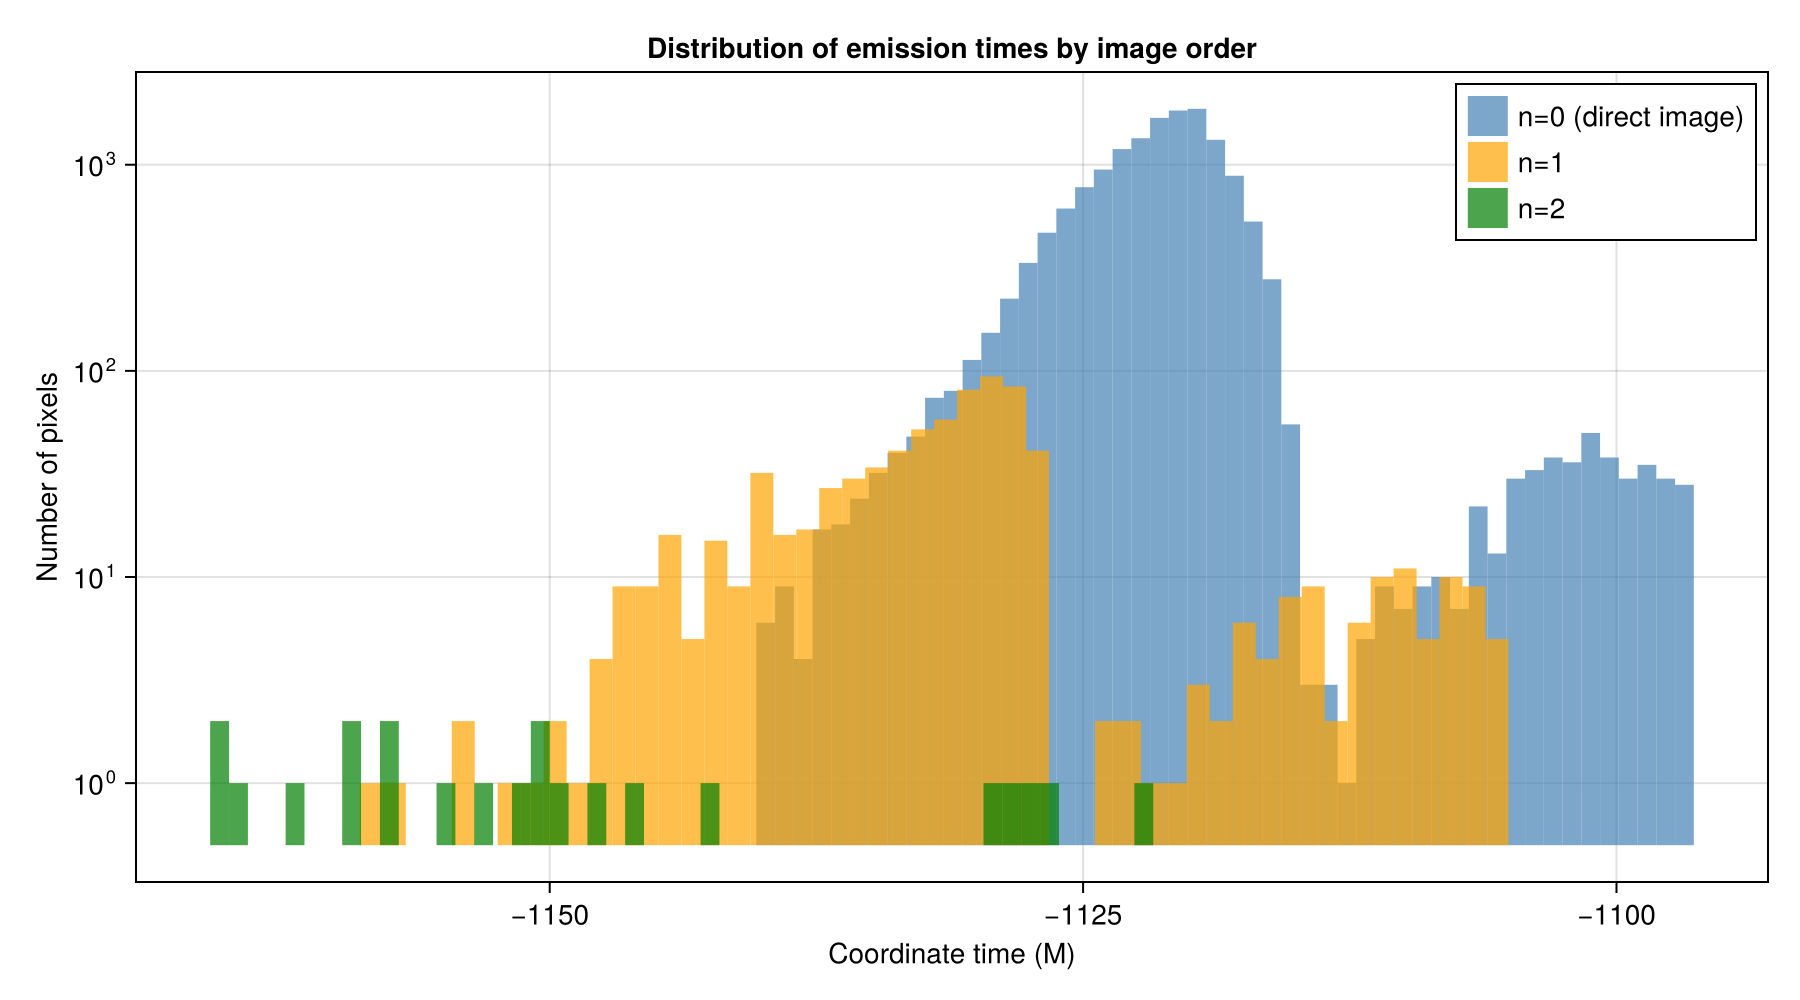

CairoMakie.Screen{IMAGE}


In [2]:
using CairoMakie

# Extraer tiempos de emisión del último paso de cada geodésica
t_emission = [all_geodesics[i,j][end].X[1] for i in 1:128, j in 1:128]

# Separar por orden de imagen
t_n0 = [t_emission[i,j] for i in 1:128, j in 1:128 if midplane_crossings[i,j] == 1]
t_n1 = [t_emission[i,j] for i in 1:128, j in 1:128 if midplane_crossings[i,j] == 2]
t_n2 = [t_emission[i,j] for i in 1:128, j in 1:128 if midplane_crossings[i,j] == 3]

# Histograma
fig = Figure(size=(900, 500))
ax = Axis(fig[1,1],
    title = "Distribution of emission times by image order",
    xlabel = "Coordinate time (M)",
    ylabel = "Number of pixels",
    yscale = log10)

hist!(ax, t_n0, bins=50, color=(:steelblue, 0.7),  label="n=0 (direct image)")
hist!(ax, t_n1, bins=50, color=(:orange,    0.7),  label="n=1")
hist!(ax, t_n2, bins=50, color=(:green,     0.7),  label="n=2")


axislegend(ax)

save("histogram_times.png", fig)
display(fig)

t̄_0 = -1120.0767996350246 M
t̄_1 = -1129.3649593834352 M
t̄_2 = -1153.5429272403937 M


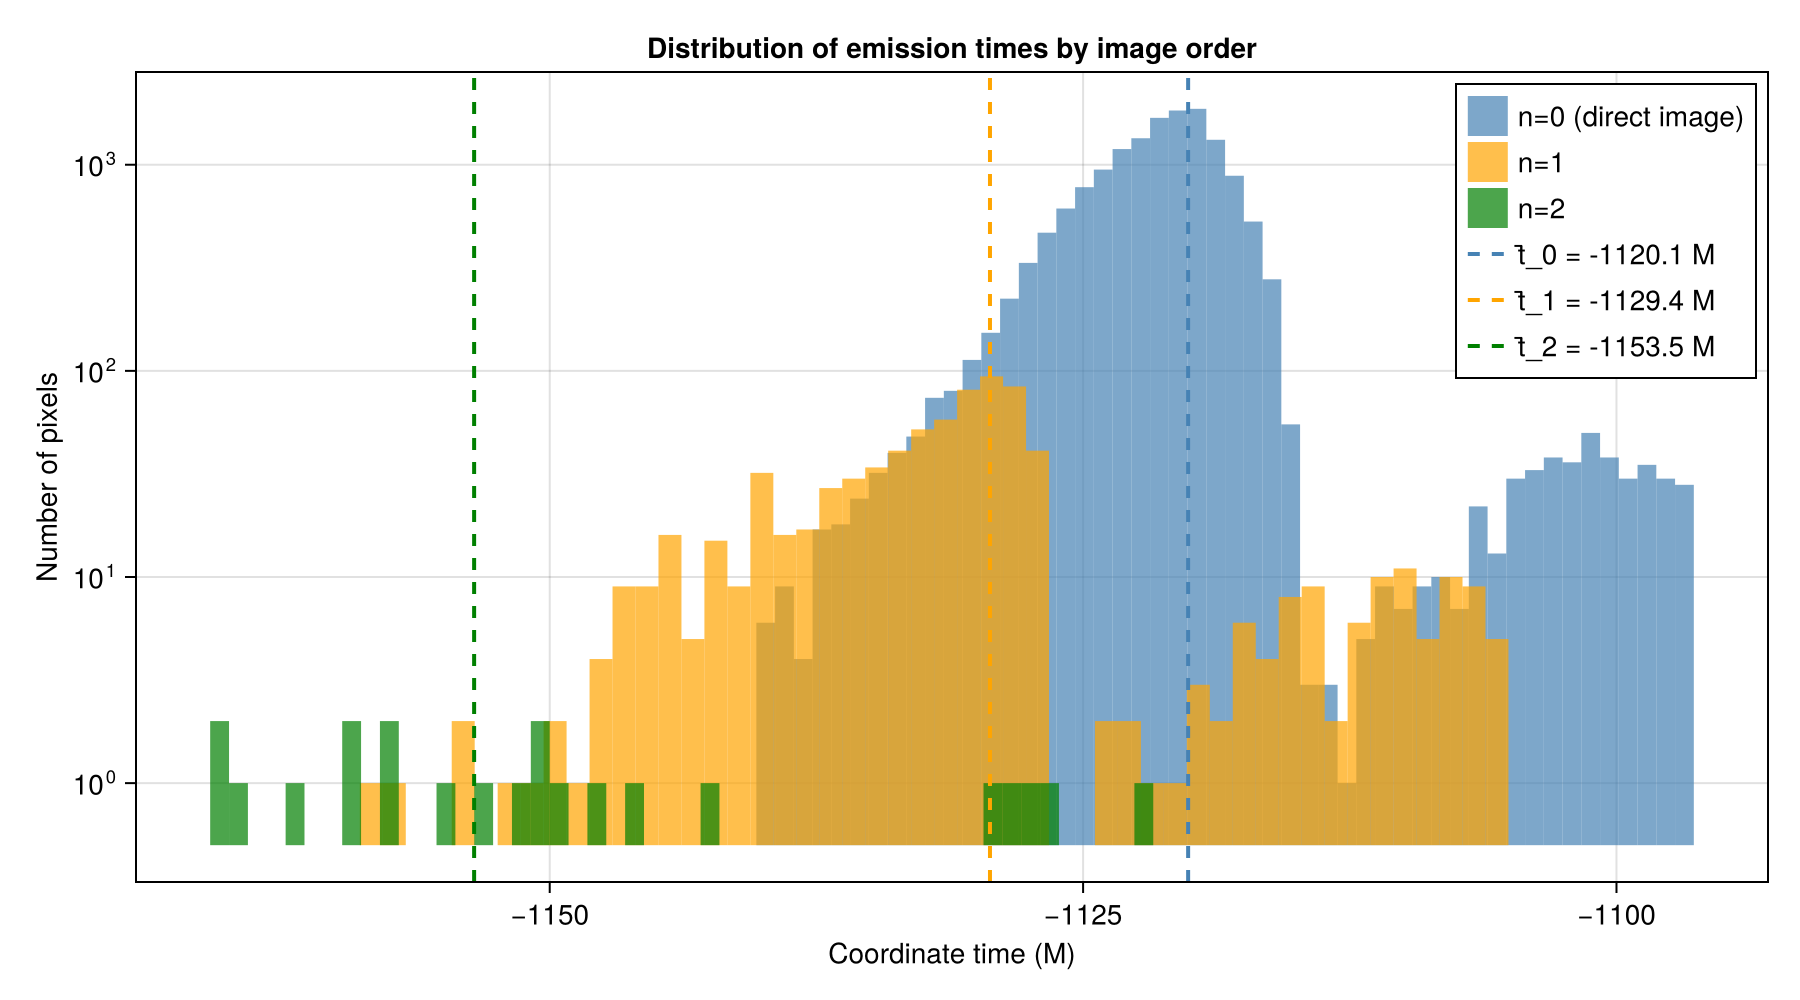

CairoMakie.Screen{IMAGE}


In [5]:
using CairoMakie
using KernelDensity
using Statistics

# Extraer tiempos de emisión
t_emission = [all_geodesics[i,j][end].X[1] for i in 1:128, j in 1:128]

t_n0 = [t_emission[i,j] for i in 1:128, j in 1:128 if midplane_crossings[i,j] == 1]
t_n1 = [t_emission[i,j] for i in 1:128, j in 1:128 if midplane_crossings[i,j] == 2]
t_n2 = [t_emission[i,j] for i in 1:128, j in 1:128 if midplane_crossings[i,j] == 3]

# Calcular tiempos modales
mode_n0 = modal_hdi_kde(t_n0, 0.0).mode
mode_n1 = modal_hdi_kde(t_n1, 0.0).mode
mode_n2 = modal_hdi_kde(t_n2, 0.0).mode

println("t̄_0 = $mode_n0 M")
println("t̄_1 = $mode_n1 M")
println("t̄_2 = $mode_n2 M")

fig = Figure(size=(900, 500))
ax = Axis(fig[1,1],
    title  = "Distribution of emission times by image order",
    xlabel = "Coordinate time (M)",
    ylabel = "Number of pixels",
    yscale = log10)

hist!(ax, t_n0, bins=50, color=(:steelblue, 0.7), label="n=0 (direct image)")
hist!(ax, t_n1, bins=50, color=(:orange,    0.7), label="n=1")
hist!(ax, t_n2, bins=50, color=(:green,     0.7), label="n=2")

vlines!(ax, [mode_n0], color=:steelblue, linewidth=2, linestyle=:dash, label="t̄_0 = $(round(mode_n0, digits=1)) M")
vlines!(ax, [mode_n1], color=:orange,    linewidth=2, linestyle=:dash, label="t̄_1 = $(round(mode_n1, digits=1)) M")
vlines!(ax, [mode_n2], color=:green,     linewidth=2, linestyle=:dash, label="t̄_2 = $(round(mode_n2, digits=1)) M")

axislegend(ax)
save("histogram_times_modal.png", fig)
display(fig)

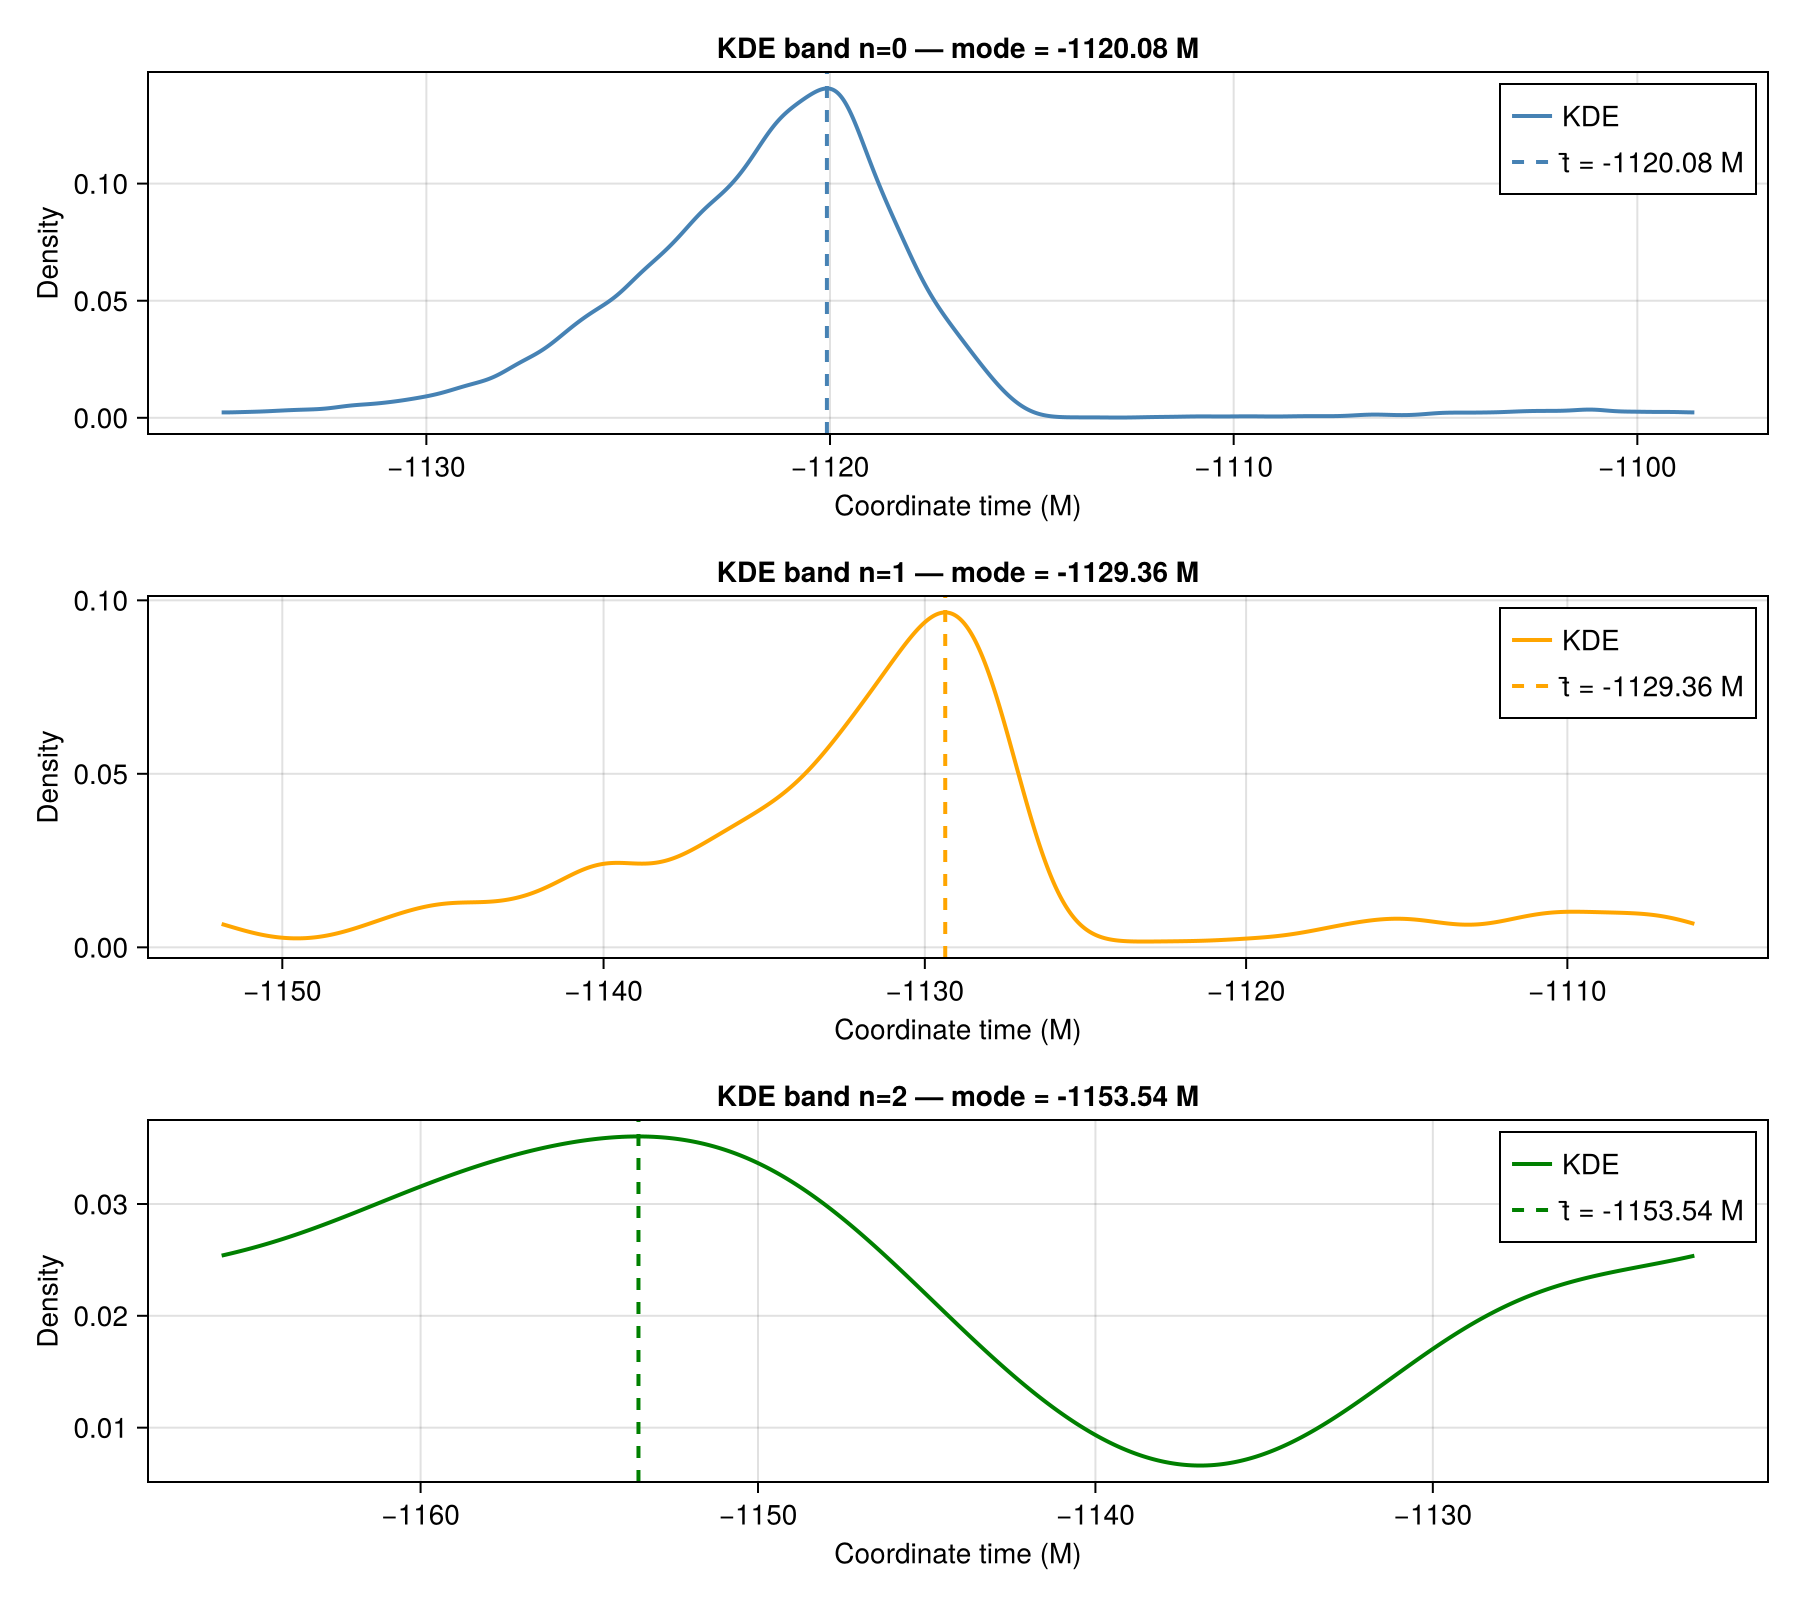

CairoMakie.Screen{IMAGE}


In [7]:
fig2 = Figure(size=(900, 800))

bands  = [t_n0,       t_n1,     t_n2]
colors = [:steelblue, :orange,  :green]
labels = ["n=0",      "n=1",    "n=2"]

for (idx, (ts, color, label)) in enumerate(zip(bands, colors, labels))
    result = modal_hdi_kde(Float64.(ts), 0.0)

    # Reconstruir la KDE para graficar la densidad
    q_low, q_high = 0.005, 0.995
    lo = quantile(filter(isfinite, Float64.(ts)), q_low)
    hi = quantile(filter(isfinite, Float64.(ts)), q_high)
    k       = kde(filter(v -> lo <= v <= hi, Float64.(ts)); boundary=(lo, hi), npoints=4096)
    x_grid  = collect(k.x)
    density = k.density

    ax = Axis(fig2[idx, 1],
        title  = "KDE band $label — mode = $(round(result.mode, digits=2)) M",
        xlabel = "Coordinate time (M)",
        ylabel = "Density")

    lines!(ax, x_grid, density,
        color     = color,
        linewidth = 2,
        label     = "KDE")

    vlines!(ax, [result.mode],
        color     = color,
        linewidth = 2,
        linestyle = :dash,
        label     = "t̄ = $(round(result.mode, digits=2)) M")

    axislegend(ax)
end

save("kde_modal_p0.png", fig2)
display(fig2)